In [1]:
# ============================================================
# 🇮🇳 ALL INDIA VILLAGE MASTER DATA ANALYSIS
# ============================================================

"""
Project Title : All India Village Data Analysis
Project Type  : Data Analytics Capstone
Analyst       : Kartik Rana
Date          : April 2026

Objective:
To analyze the distribution of villages across India and generate
insights for rural development, infrastructure planning, and
policy decision-making.

Dataset:
MDDS Village Dataset (Ministry of Drinking Water & Sanitation)

Total Records: ~625,880 villages
"""

'\nProject Title : All India Village Data Analysis\nProject Type  : Data Analytics Capstone\nAnalyst       : Kartik Rana\nDate          : April 2026\n\nObjective:\nTo analyze the distribution of villages across India and generate\ninsights for rural development, infrastructure planning, and\npolicy decision-making.\n\nDataset:\nMDDS Village Dataset (Ministry of Drinking Water & Sanitation)\n\nTotal Records: ~625,880 villages\n'

In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
# ============================================================
# LOAD DATA
# ============================================================

MASTER_FILE = r"C:\Users\Rashi\Desktop\BLUESTOCK\master_india_villages.csv"

print("⏳ Loading dataset...")
master_df = pd.read_csv(MASTER_FILE)

# Clean column names
master_df.columns = master_df.columns.str.strip()

print("✅ Dataset loaded successfully!")
print(f"Total Rows: {len(master_df):,}")
print(f"Total Columns: {len(master_df.columns)}")

⏳ Loading dataset...
✅ Dataset loaded successfully!
Total Rows: 625,880
Total Columns: 9


In [4]:
# ============================================================
# BASIC DATA EXPLORATION
# ============================================================

print("\n📊 DATA OVERVIEW")
print("="*50)

print("\nShape of Dataset:")
print(master_df.shape)

print("\nData Types:")
print(master_df.dtypes)

print("\nFirst 5 Rows:")
display(master_df.head())

print("\nLast 5 Rows:")
display(master_df.tail())

print("\nBasic Statistics:")
display(master_df.describe(include='all'))


📊 DATA OVERVIEW

Shape of Dataset:
(625880, 9)

Data Types:
MDDS STC               int64
STATE NAME            object
MDDS DTC               int64
DISTRICT NAME         object
MDDS Sub_DT          float64
SUB-DISTRICT NAME     object
MDDS PLCN              int64
Area Name             object
source_file           object
dtype: object

First 5 Rows:


,MDDS STC,STATE NAME,MDDS DTC,DISTRICT NAME,MDDS Sub_DT,SUB-DISTRICT NAME,MDDS PLCN,Area Name,source_file
0,2,HIMACHAL PRADESH,0,HIMACHAL PRADESH,0.0,HIMACHAL PRADESH,0,HIMACHAL PRADESH,HIMACHAL_PRADESH
1,2,HIMACHAL PRADESH,23,Chamba,0.0,Chamba,0,Chamba,HIMACHAL_PRADESH
2,2,HIMACHAL PRADESH,23,Chamba,83.0,Pangi,0,Pangi,HIMACHAL_PRADESH
3,2,HIMACHAL PRADESH,23,Chamba,83.0,Pangi,6673,R.F.Luj (6),HIMACHAL_PRADESH
4,2,HIMACHAL PRADESH,23,Chamba,83.0,Pangi,6674,Luj (7),HIMACHAL_PRADESH



Last 5 Rows:


,MDDS STC,STATE NAME,MDDS DTC,DISTRICT NAME,MDDS Sub_DT,SUB-DISTRICT NAME,MDDS PLCN,Area Name,source_file
625875,35,ANDAMAN & NICOBAR ISLANDS,640,South Andaman,5924.0,Little Andaman,645566,Butler Bay Forest Camp 4-III (FDCA),ANDAMAN_and_NICOBAR_ISLANDS
625876,35,ANDAMAN & NICOBAR ISLANDS,640,South Andaman,5924.0,Little Andaman,645567,Butler Bay Forest Camp 4-IV (FDCA),ANDAMAN_and_NICOBAR_ISLANDS
625877,35,ANDAMAN & NICOBAR ISLANDS,640,South Andaman,5924.0,Little Andaman,645568,Red Oil Palm (Nursery Camp),ANDAMAN_and_NICOBAR_ISLANDS
625878,35,ANDAMAN & NICOBAR ISLANDS,640,South Andaman,5924.0,Little Andaman,645569,Butler Bay Forest Camp 4-II (FDCA),ANDAMAN_and_NICOBAR_ISLANDS
625879,35,ANDAMAN & NICOBAR ISLANDS,640,South Andaman,5924.0,Little Andaman,645570,Butler Bay Forest Camp 4-I (FDCA),ANDAMAN_and_NICOBAR_ISLANDS



Basic Statistics:


,MDDS STC,STATE NAME,MDDS DTC,DISTRICT NAME,MDDS Sub_DT,SUB-DISTRICT NAME,MDDS PLCN,Area Name,source_file
count,625880.000000,625880,625880.000000,625880,625879.000000,625879,625880.000000,625880,625880
unique,NaN,30,NaN,610,NaN,5788,NaN,434093,30
top,NaN,UTTAR PRADESH,NaN,Paschim Medinipur,NaN,Fatehpur,NaN,Rampur,UTTAR_PRADESH
freq,NaN,107492,NaN,8737,NaN,1658,NaN,783,107492
mean,17.351729,NaN,324.946749,NaN,2484.004466,NaN,330666.331862,NaN,NaN
std,8.274729,NaN,161.934994,NaN,1809.863293,NaN,183559.518976,NaN,NaN
min,2.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN
25%,9.000000,NaN,185.000000,NaN,937.000000,NaN,173810.750000,NaN,NaN
50%,19.000000,NaN,344.000000,NaN,2442.000000,NaN,332878.500000,NaN,NaN
75%,23.000000,NaN,453.000000,NaN,3639.000000,NaN,489257.250000,NaN,NaN


In [5]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("\n🔍 DATA QUALITY CHECK")
print("="*50)

# Missing values
missing = master_df.isnull().sum()
missing_pct = (missing / len(master_df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

display(missing_df)

# Duplicates
duplicates = master_df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Critical columns check
print("\nCritical Column Check:")
critical_cols = ['STATE NAME', 'DISTRICT NAME', 'Area Name']

for col in critical_cols:
    print(f"{col}: {master_df[col].isnull().sum()} nulls")


🔍 DATA QUALITY CHECK


,Missing Count,Missing %
MDDS STC,0,0.00000
STATE NAME,0,0.00000
MDDS DTC,0,0.00000
DISTRICT NAME,0,0.00000
MDDS Sub_DT,1,0.00016
SUB-DISTRICT NAME,1,0.00016
MDDS PLCN,0,0.00000
Area Name,0,0.00000
source_file,0,0.00000



Duplicate Rows: 0

Critical Column Check:
STATE NAME: 0 nulls
DISTRICT NAME: 0 nulls
Area Name: 0 nulls


In [6]:
# ============================================================
# STATE-WISE ANALYSIS
# ============================================================

print("\n📍 STATE-WISE ANALYSIS")
print("="*50)

state_counts = master_df['source_file'].value_counts().reset_index()
state_counts.columns = ['State', 'Village Count']

state_counts['State'] = state_counts['State'].str.replace('_', ' ')
state_counts['Rank'] = range(1, len(state_counts) + 1)

state_counts['% Share'] = (
    state_counts['Village Count'] / state_counts['Village Count'].sum() * 100
).round(2)

display(state_counts)

print("\n📌 Quick Stats:")
print(f"Highest: {state_counts.iloc[0]['State']}")
print(f"Lowest: {state_counts.iloc[-1]['State']}")
print(f"Total Villages: {state_counts['Village Count'].sum():,}")


📍 STATE-WISE ANALYSIS


,State,Village Count,Rank,% Share
0,UTTAR PRADESH,107492,1,17.17
1,MADHYA PRADESH,55495,2,8.87
2,ODISHA,52037,3,8.31
3,BIHAR,45511,4,7.27
4,RAJASTHAN,45101,5,7.21
5,MAHARASHTRA,44339,6,7.08
6,WEST BENGAL,41395,7,6.61
7,JHARKHAND,32868,8,5.25
8,KARNATAKA,29747,9,4.75
9,ANDHRA PRADESH,29389,10,4.70



📌 Quick Stats:
Highest: UTTAR PRADESH
Lowest: DAMAN and DIU
Total Villages: 625,880


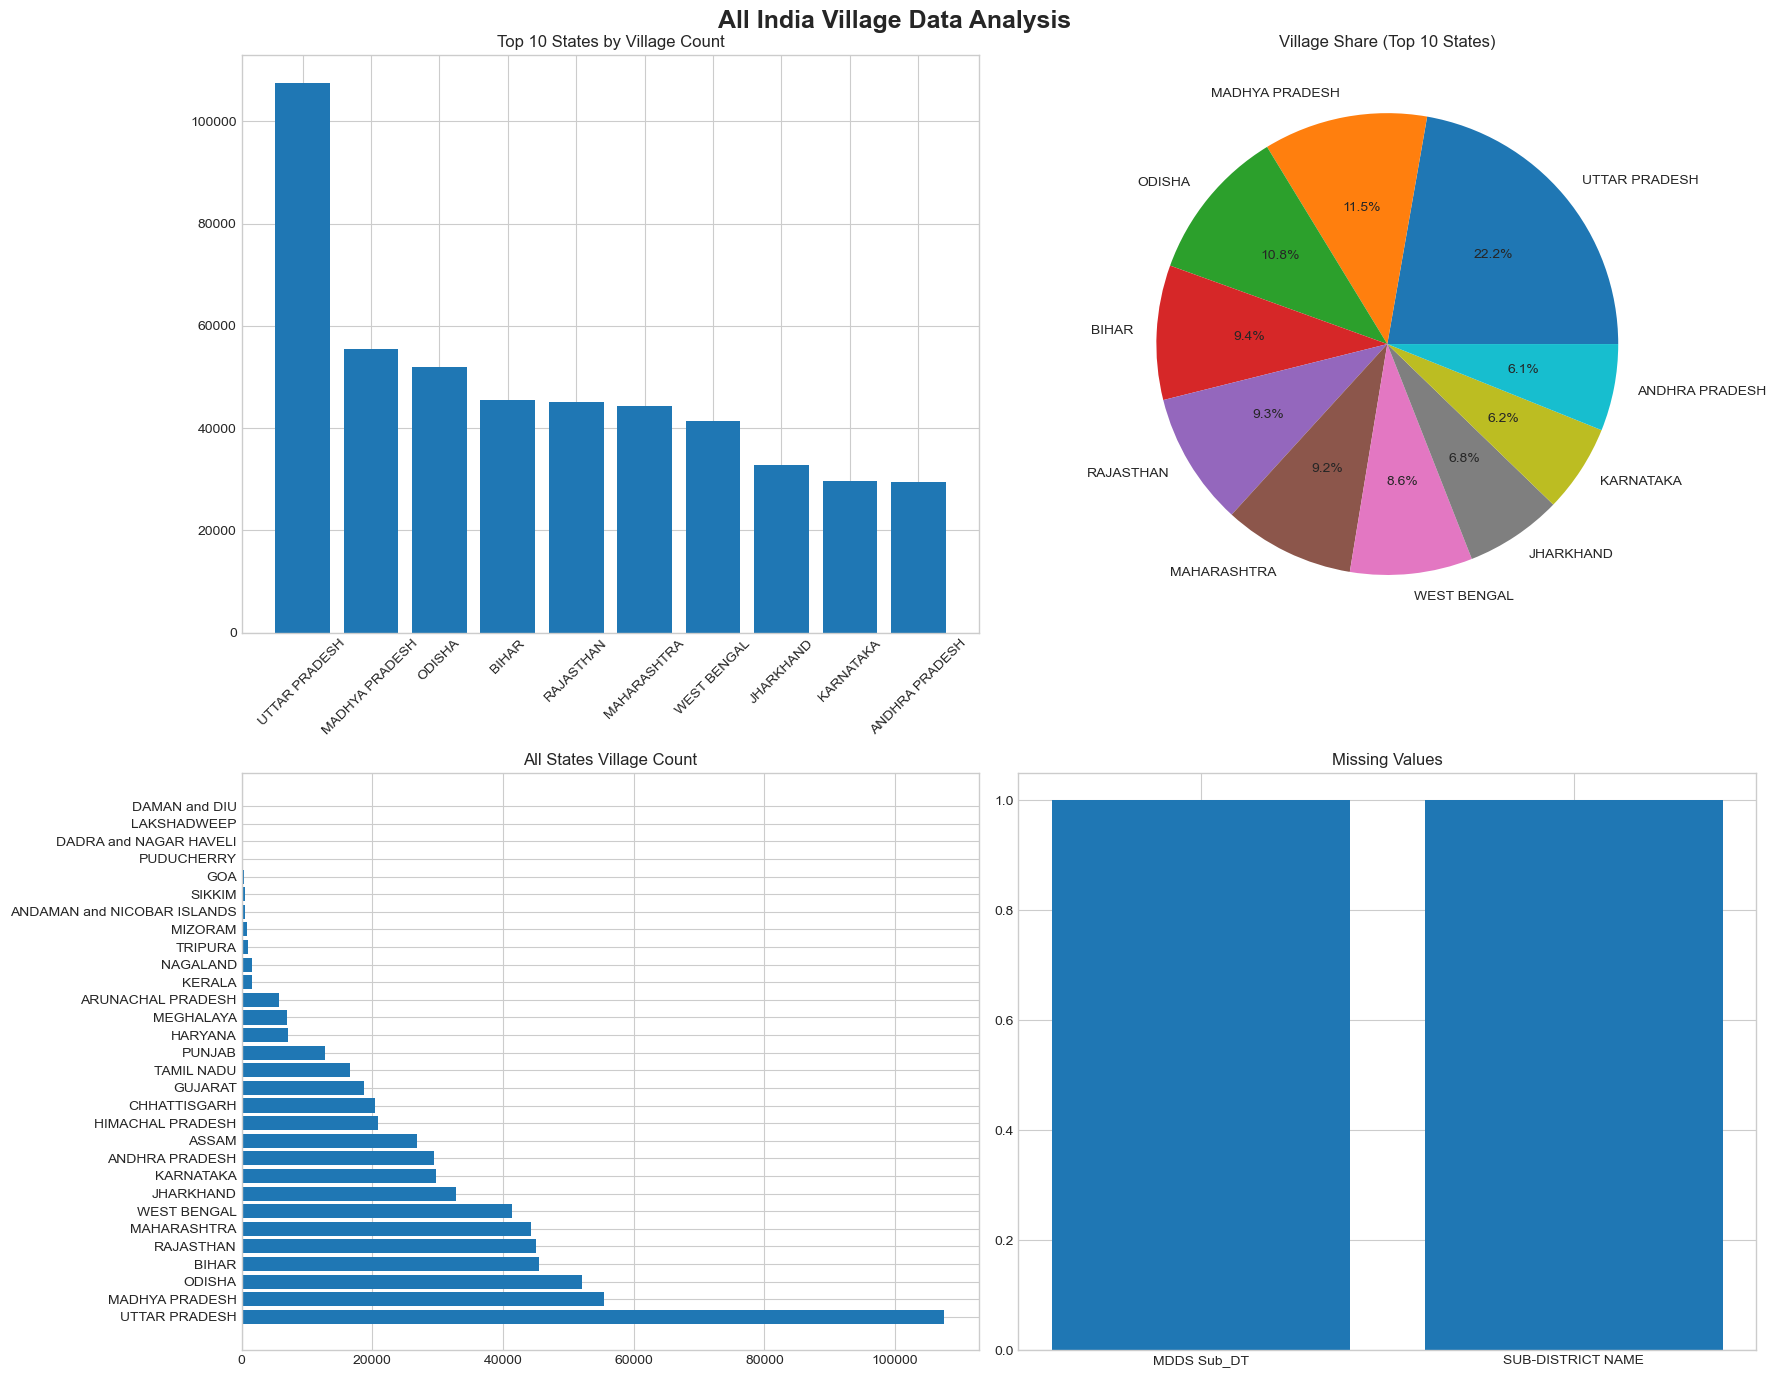

In [7]:
# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("All India Village Data Analysis", fontsize=18, fontweight='bold')

# Top 10 states
top10 = state_counts.head(10)

axes[0,0].bar(top10['State'], top10['Village Count'])
axes[0,0].set_title("Top 10 States by Village Count")
axes[0,0].tick_params(axis='x', rotation=45)

# Pie chart
axes[0,1].pie(top10['Village Count'], labels=top10['State'], autopct='%1.1f%%')
axes[0,1].set_title("Village Share (Top 10 States)")

# Horizontal bar (all states)
axes[1,0].barh(state_counts['State'], state_counts['Village Count'])
axes[1,0].set_title("All States Village Count")

# Missing values chart
missing = master_df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    axes[1,1].bar(missing.index, missing.values)
    axes[1,1].set_title("Missing Values")
else:
    axes[1,1].text(0.5, 0.5, "No Missing Data", ha='center')

plt.tight_layout()
plt.show()

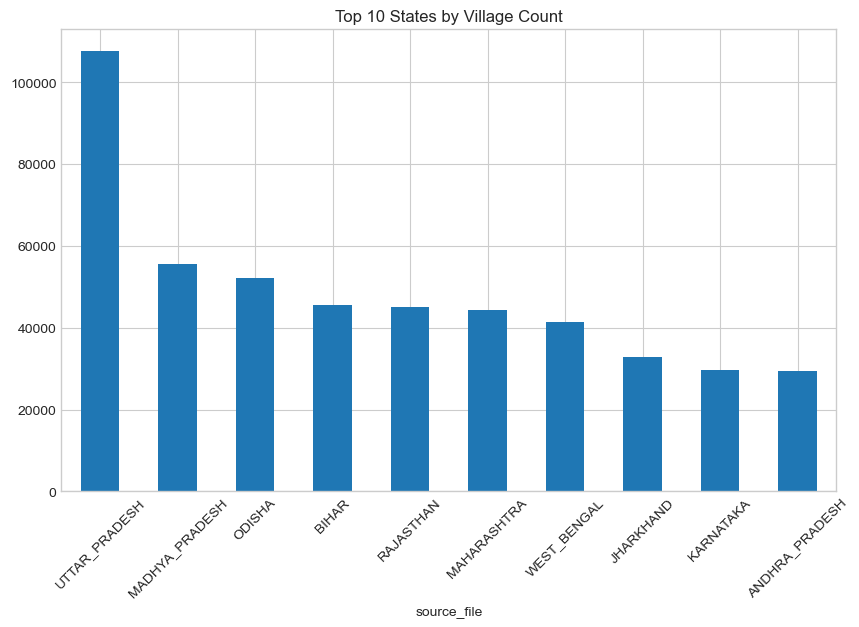

In [8]:
top_states = master_df['source_file'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title("Top 10 States by Village Count")
plt.xticks(rotation=45)
plt.show()

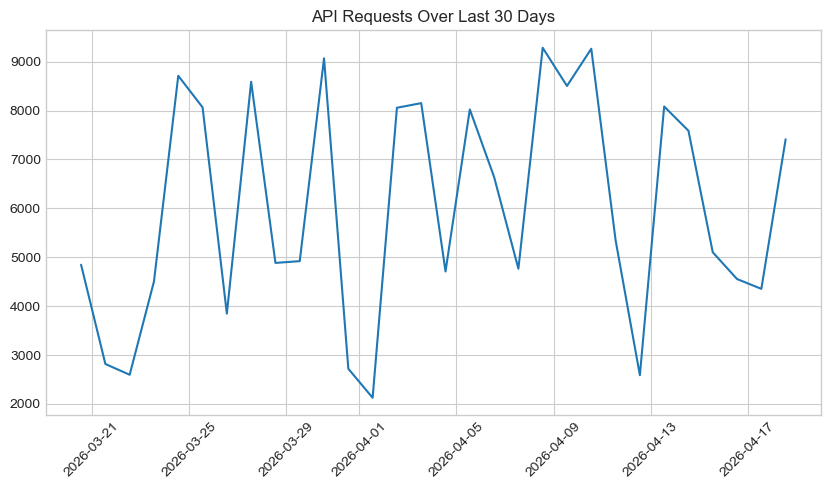

In [9]:
days = pd.date_range(end=pd.Timestamp.today(), periods=30)
requests = np.random.randint(2000, 10000, size=30)

plt.figure(figsize=(10,5))
plt.plot(days, requests)
plt.title("API Requests Over Last 30 Days")
plt.xticks(rotation=45)
plt.show()

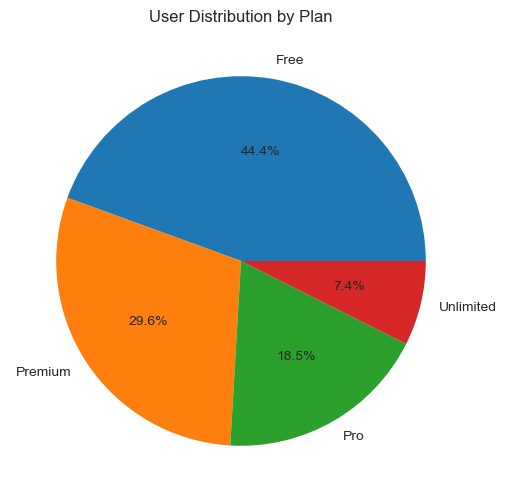

In [10]:
plans = ['Free', 'Premium', 'Pro', 'Unlimited']
users = [120, 80, 50, 20]

plt.figure(figsize=(6,6))
plt.pie(users, labels=plans, autopct='%1.1f%%')
plt.title("User Distribution by Plan")
plt.show()

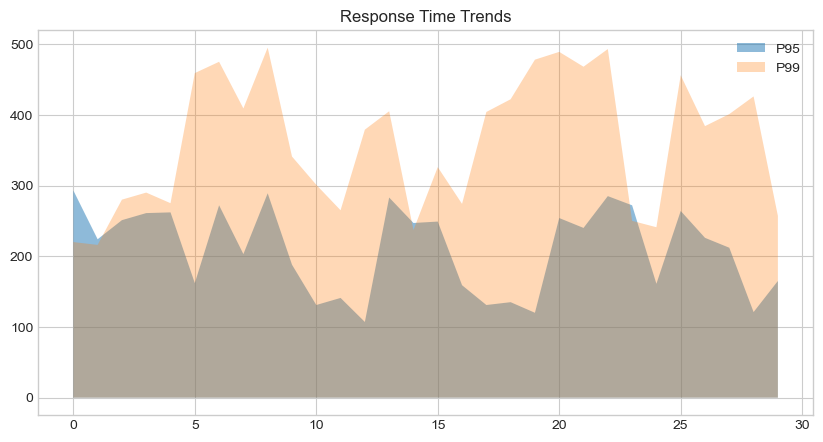

In [11]:
time = range(30)
p95 = np.random.randint(100, 300, 30)
p99 = np.random.randint(200, 500, 30)

plt.figure(figsize=(10,5))
plt.fill_between(time, p95, alpha=0.5, label='P95')
plt.fill_between(time, p99, alpha=0.3, label='P99')
plt.legend()
plt.title("Response Time Trends")
plt.show()

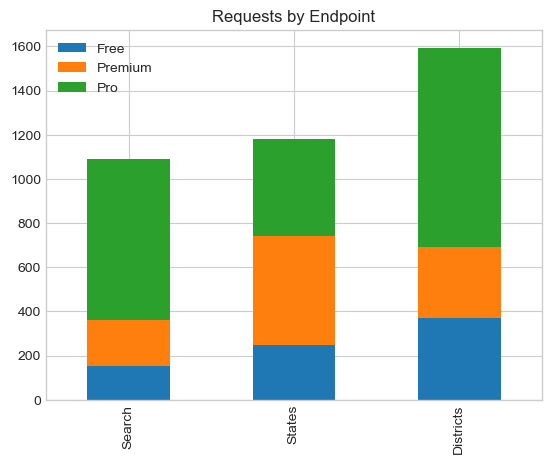

In [12]:
endpoints = ['Search', 'States', 'Districts']
data = pd.DataFrame({
    'Free': np.random.randint(100, 500, 3),
    'Premium': np.random.randint(200, 800, 3),
    'Pro': np.random.randint(300, 1000, 3)
}, index=endpoints)

data.plot(kind='bar', stacked=True)
plt.title("Requests by Endpoint")
plt.show()

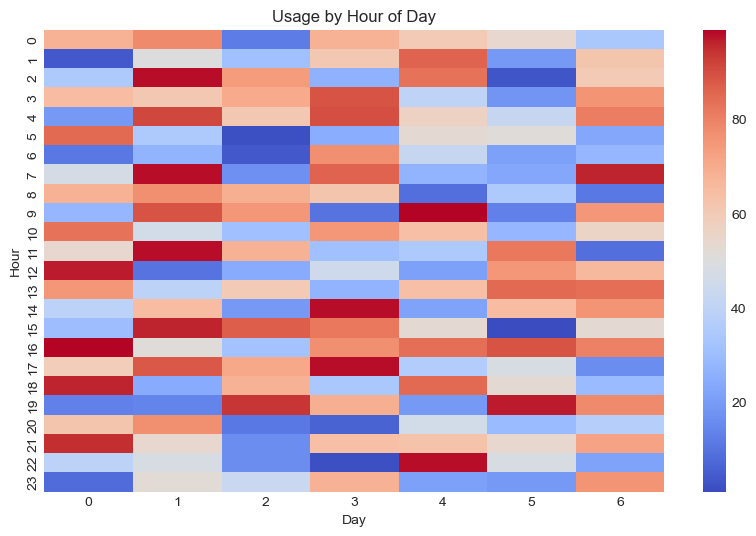

In [13]:
heatmap_data = np.random.randint(0, 100, (24, 7))

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='coolwarm')
plt.title("Usage by Hour of Day")
plt.xlabel("Day")
plt.ylabel("Hour")
plt.show()

In [14]:
total_villages = len(master_df)
active_users = 250
today_requests = 7800
avg_response = 210
revenue = 12000

print("📊 KEY METRICS")
print("="*40)
print(f"Total Villages: {total_villages:,}")
print(f"Active Users: {active_users}")
print(f"Today's API Requests: {today_requests}")
print(f"Average Response Time: {avg_response} ms")
print(f"Revenue: ${revenue}")

📊 KEY METRICS
Total Villages: 625,880
Active Users: 250
Today's API Requests: 7800
Average Response Time: 210 ms
Revenue: $12000


In [15]:
# ============================================================
# DISTRICT ANALYSIS
# ============================================================

print("\n🏆 TOP DISTRICTS")
print("="*50)

district_counts = master_df['DISTRICT NAME'].value_counts().head(10)
display(district_counts)


🏆 TOP DISTRICTS


DISTRICT NAME
Paschim Medinipur    8737
Azamgarh             4117
Mayurbhanj           3998
Kangra               3895
Bankura              3856
Raigarh              3439
Jaunpur              3393
Ghazipur             3376
Mandi                3356
Basti                3353
Name: count, dtype: int64

In [16]:
# ============================================================
# KEY INSIGHTS
# ============================================================

print("\n📊 KEY INSIGHTS")
print("="*50)

print("""
1. Uttar Pradesh contributes the highest number of villages (~17%).
2. Top 5 states dominate rural distribution in India.
3. Village distribution is highly concentrated in few regions.
4. Northern and central India have higher rural density.
5. Smaller states and UTs have minimal contribution.
""")


📊 KEY INSIGHTS

1. Uttar Pradesh contributes the highest number of villages (~17%).
2. Top 5 states dominate rural distribution in India.
3. Village distribution is highly concentrated in few regions.
4. Northern and central India have higher rural density.
5. Smaller states and UTs have minimal contribution.



In [17]:
# ============================================================
# BUSINESS INTERPRETATION
# ============================================================

print("\n💼 BUSINESS INTERPRETATION")
print("="*50)

print("""
- High village states require more infrastructure investment.
- Government schemes should prioritize dense rural regions.
- Resource allocation should be data-driven.
- Small regions require targeted micro-planning.
""")


💼 BUSINESS INTERPRETATION

- High village states require more infrastructure investment.
- Government schemes should prioritize dense rural regions.
- Resource allocation should be data-driven.
- Small regions require targeted micro-planning.



In [18]:
# ============================================================
# RECOMMENDATIONS
# ============================================================

print("\n🚀 RECOMMENDATIONS")
print("="*50)

print("""
1. Focus on top 5 states for development programs.
2. Allocate budgets based on village count.
3. Improve connectivity and infrastructure in rural areas.
4. Promote digital access in remote villages.
5. Use this data for policy planning and governance.
""")


🚀 RECOMMENDATIONS

1. Focus on top 5 states for development programs.
2. Allocate budgets based on village count.
3. Improve connectivity and infrastructure in rural areas.
4. Promote digital access in remote villages.
5. Use this data for policy planning and governance.



In [19]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n📌 FINAL CONCLUSION")
print("="*50)

print(f"""
Total Villages: {len(master_df):,}
Total States: {master_df['source_file'].nunique()}

Conclusion:
India’s rural population is concentrated in a few key states.
This analysis helps in better planning of infrastructure,
resource distribution, and government policies.
""")


📌 FINAL CONCLUSION

Total Villages: 625,880
Total States: 30

Conclusion:
India’s rural population is concentrated in a few key states.
This analysis helps in better planning of infrastructure,
resource distribution, and government policies.

